# Download necessary libbraries

In [ ]:
from pathlib import Path
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
import statsmodels.formula.api as smf

Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
FILE_PATH = "/content/drive/MyDrive/Copy of Finalized Dataset.csv"
OUTPUT_DIR = Path("/content/acne_misinfo_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



# Presentation palette
SLIDE_PINK = "#C98B98"
SLIDE_BLUE = "#5C93AC"
BLUSH = "#EADFDD"
TAN = "#D9C1B6"
BROWN = "#B37A3A"
CHARCOAL = "#2F2F2F"
SOFT_GRAY = "#666666"
EDGE = "#444444"

LABEL_COLORS = {
    "yes": SLIDE_PINK,
    "no": BLUSH,
    "not_sure": TAN,
}

sns.set_style("whitegrid")


In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

FONT_PATH = "/content/EBGaramond.ttf"

if not os.path.exists(FONT_PATH):
    !wget -q -O /content/EBGaramond.ttf "https://github.com/google/fonts/raw/main/ofl/ebgaramond/EBGaramond%5Bwght%5D.ttf"

fm.fontManager.addfont(FONT_PATH)
PRESENTATION_FONT = fm.FontProperties(fname=FONT_PATH).get_name()
FONT_PROP = fm.FontProperties(family=PRESENTATION_FONT)

plt.rcParams["font.family"] = PRESENTATION_FONT


In [ ]:
# ============================================================
# 2. Data CleanUp
# ============================================================

df = pd.read_csv(FILE_PATH)
df["posting_date"] = pd.to_datetime(df["posting_date"], errors="coerce")

for col in [
    "creator_followers",
    "views",
    "likes",
    "comments",
    "shares",
    "engagement_rate",
    "video_duration_seconds",
    "video_shot_complexity",
    "No._people_video",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
# ============================================================
# 3. HELPERS
# ============================================================

def apply_axis_font(ax):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(fm.FontProperties(fname=FONT_PATH))


def remove_spines(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


def save_figure(fig, filename):
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.close(fig)


def count_items(x):
    if pd.isna(x):
        return 0
    x = str(x).strip()
    if x.lower() in {"", "none", "unknown", "unclear", "na", "nan", "no link"}:
        return 0
    return len([p.strip() for p in x.split(",") if p.strip()])


def cramers_v(x, y):
    table = pd.crosstab(x, y)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)


In [ ]:
def apply_axis_font(ax):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(FONT_PROP)

    ax.title.set_fontproperties(FONT_PROP)
    ax.xaxis.label.set_fontproperties(FONT_PROP)
    ax.yaxis.label.set_fontproperties(FONT_PROP)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontproperties(FONT_PROP)


# EAD

Saved: /content/acne_misinfo_outputs/creator_type_pie_chart.png


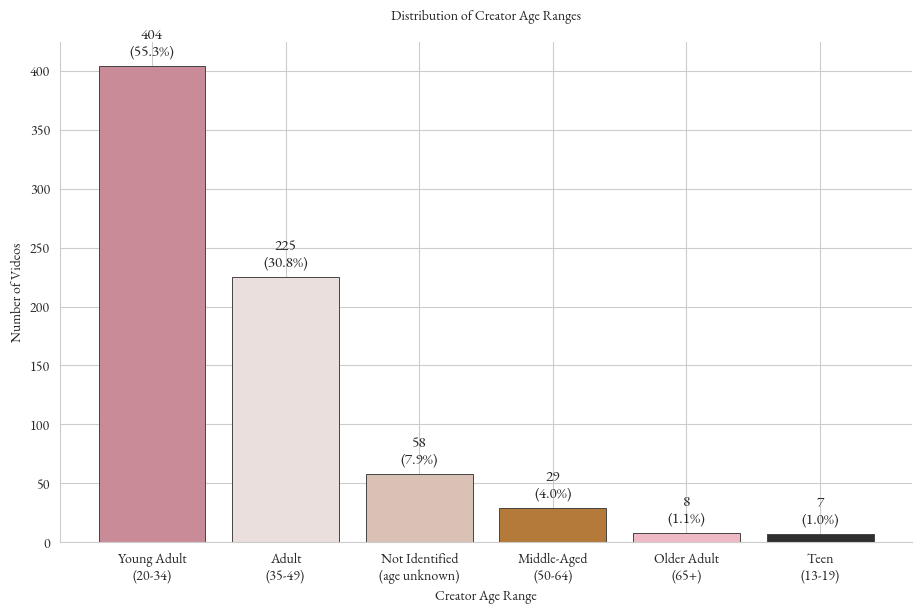

In [ ]:

# ============================================================
# 4. DATA SUMMARY CHARTS
# ============================================================

# 4.1 Creator type pie chart
creator_counts = (
    df["creator_type"]
    .value_counts()
    .reindex(["influencer", "dermatologist", "patient", "other"])
    .fillna(0)
    .astype(int)
)
creator_pct = (creator_counts / creator_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9.5, 7))
labels = [
    f"Influencer\n{creator_counts['influencer']} ({creator_pct['influencer']}%)",
    f"Dermatologist\n{creator_counts['dermatologist']} ({creator_pct['dermatologist']}%)",
    f"Patient\n{creator_counts['patient']} ({creator_pct['patient']}%)",
    f"Other\n{creator_counts['other']} ({creator_pct['other']}%)",
]
ax.pie(
    creator_counts.values,
    labels=labels,
    colors=[SLIDE_PINK, BLUSH, BROWN, TAN],
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": EDGE, "linewidth": 0.8},
    textprops={"fontsize": 12},
    labeldistance=1.08,
)
ax.set_title("Distribution of Creator Types", fontsize=24, pad=18, color=CHARCOAL)
ax.axis("equal")
save_figure(fig, "creator_type_pie_chart.png")


# 4.2 Age range bar chart
age_order = [
    "young_adult",
    "adult",
    "not_identified",
    "middle_aged",
    "older_adult",
    "teen",
]
age_counts = df["creator_age_range"].value_counts().reindex(age_order).fillna(0).astype(int)
age_pct = (age_counts / len(df) * 100).round(1)
age_labels = {
    "young_adult": "Young Adult\n(20-34)",
    "adult": "Adult\n(35-49)",
    "not_identified": "Not Identified\n(age unknown)",
    "middle_aged": "Middle-Aged\n(50-64)",
    "older_adult": "Older Adult\n(65+)",
    "teen": "Teen\n(13-19)",
}

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.bar(
    range(len(age_counts)),
    age_counts.values,
    color=[SLIDE_PINK, BLUSH, TAN, BROWN, "#EFB9C6", CHARCOAL],
    edgecolor=EDGE,
    linewidth=0.7,
)
for bar, count, pct in zip(bars, age_counts.values, age_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 6,
        f"{count}\n({pct}%)",
        ha="center",
        va="bottom",
        fontsize=11,
    )
ax.set_title("Distribution of Creator Age Ranges", fontsize=22, pad=16)
ax.set_xlabel("Creator Age Range", fontsize=14)
ax.set_ylabel("Number of Videos", fontsize=14)
ax.set_xticks(range(len(age_counts)))
ax.set_xticklabels([age_labels[i] for i in age_counts.index], fontsize=12)
apply_axis_font(ax)
remove_spines(ax)




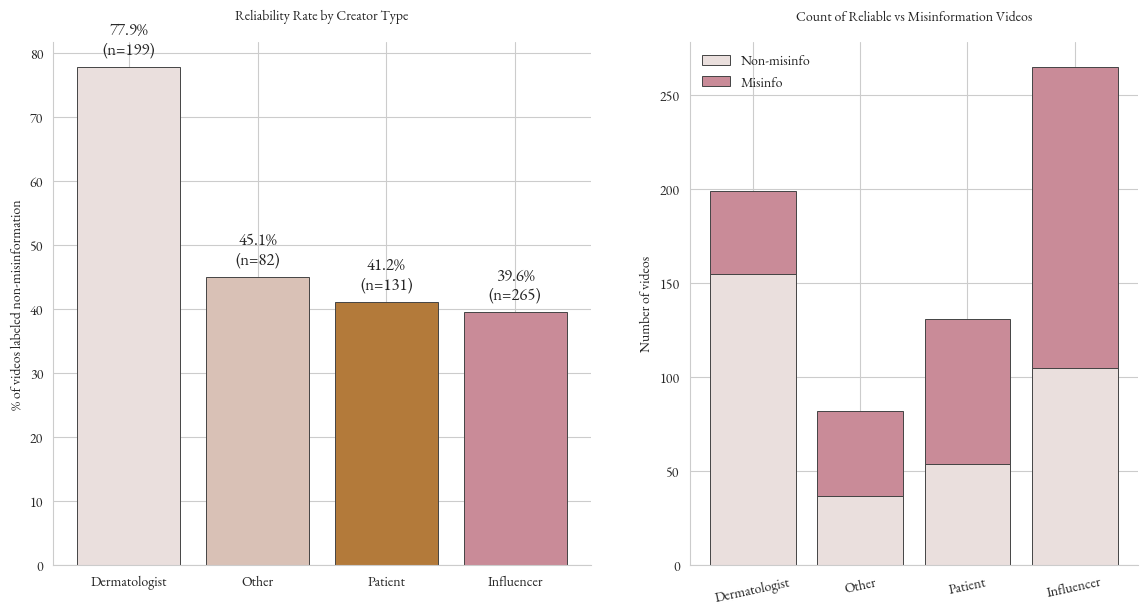

In [ ]:
# ============================================================
# 5. EDA 1: CREATOR TYPE VS RELIABILITY
# ============================================================

df_binary = df[df["misinfo_label"].isin(["yes", "no"])].copy()
df_binary["reliable"] = (df_binary["misinfo_label"] == "no").astype(int)

summary = (
    df_binary.groupby("creator_type")
    .agg(reliability_rate=("reliable", "mean"), n=("reliable", "size"))
    .reindex(["dermatologist", "other", "patient", "influencer"])
)
summary["reliability_pct"] = (summary["reliability_rate"] * 100).round(1)
ct = pd.crosstab(df_binary["creator_type"], df_binary["misinfo_label"]).reindex(
    ["dermatologist", "other", "patient", "influencer"]
)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6.8), gridspec_kw={"width_ratios": [1.2, 1]}
)

labels = ["Dermatologist", "Other", "Patient", "Influencer"]
bars = ax1.bar(
    labels,
    summary["reliability_pct"],
    color=[BLUSH, TAN, BROWN, SLIDE_PINK],
    edgecolor=EDGE,
    linewidth=0.7,
)
for rect, pct, n in zip(bars, summary["reliability_pct"], summary["n"]):
    ax1.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1.2,
        f"{pct}%\n(n={n})",
        ha="center",
        va="bottom",
        fontsize=12,
    )
ax1.set_title("Reliability Rate by Creator Type", fontsize=22, pad=16)
ax1.set_ylabel("% of videos labeled non-misinformation", fontsize=13)
apply_axis_font(ax1)
remove_spines(ax1)

x = range(len(labels))
ax2.bar(x, ct["no"].values, color=BLUSH, edgecolor=EDGE, linewidth=0.7, label="Non-misinfo")
ax2.bar(
    x,
    ct["yes"].values,
    bottom=ct["no"].values,
    color=SLIDE_PINK,
    edgecolor=EDGE,
    linewidth=0.7,
    label="Misinfo",
)
ax2.set_title("Count of Reliable vs Misinformation Videos", fontsize=22, pad=16)
ax2.set_ylabel("Number of videos", fontsize=13)
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels, rotation=12)
apply_axis_font(ax2)
remove_spines(ax2)
ax2.legend(frameon=False)



Saved: /content/acne_misinfo_outputs/creator_type_vs_reliability.png


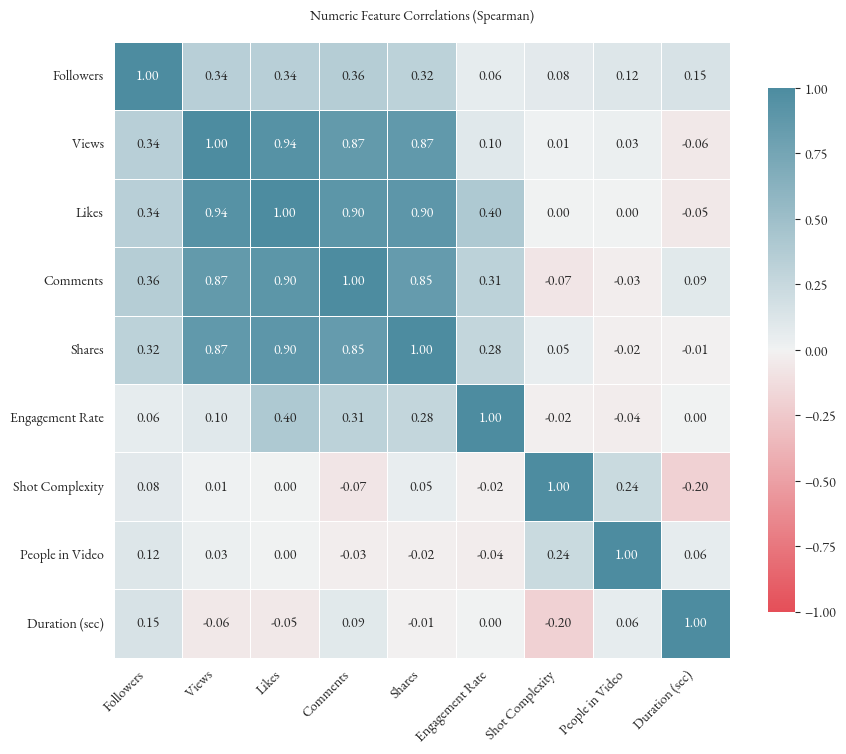

In [ ]:

# ============================================================
# 6. EDA 2: NUMERIC CORRELATION HEATMAP
# ============================================================

num = pd.DataFrame(
    {
        "Followers": df["creator_followers"],
        "Views": df["views"],
        "Likes": df["likes"],
        "Comments": df["comments"],
        "Shares": df["shares"],
        "Engagement Rate": df["engagement_rate"],
        "Shot Complexity": df["video_shot_complexity"],
        "People in Video": df["No._people_video"],
        "Duration (sec)": df["video_duration_seconds"],
    }
)
num_corr = num.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    num_corr,
    cmap=sns.diverging_palette(10, 220, s=70, l=55, as_cmap=True),
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.85},
    ax=ax,
)
ax.set_title("Numeric Feature Correlations (Spearman)", fontsize=24, pad=16)
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")
apply_axis_font(ax)


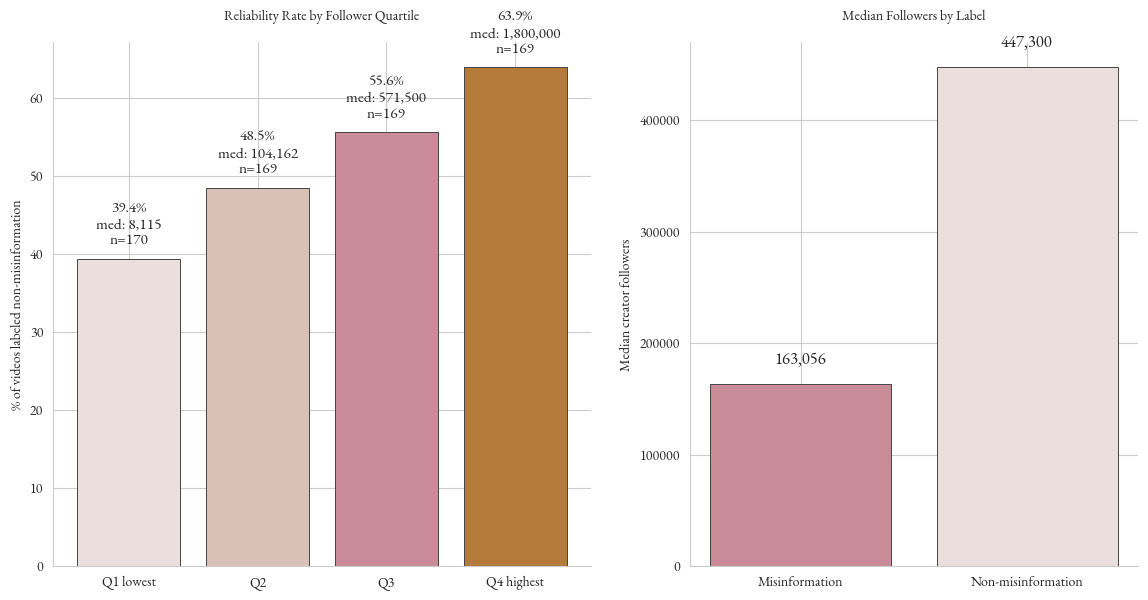

In [ ]:
# ============================================================
# 8. EDA 4: FOLLOWERS VS RELIABILITY
# ============================================================

sub = df[df["misinfo_label"].isin(["yes", "no"])].copy()
sub["reliable"] = (sub["misinfo_label"] == "no").astype(int)
sub["follower_quartile"] = pd.qcut(
    sub["creator_followers"].rank(method="first"),
    4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
)
quart = (
    sub.groupby("follower_quartile", observed=False)
    .agg(
        reliability_rate=("reliable", "mean"),
        median_followers=("creator_followers", "median"),
        n=("reliable", "size"),
    )
    .reset_index()
)
quart["reliability_pct"] = (quart["reliability_rate"] * 100).round(1)
summary = sub.groupby("misinfo_label")["creator_followers"].median().reindex(["yes", "no"])

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6.8), gridspec_kw={"width_ratios": [1.2, 1]}
)
bars = ax1.bar(
    quart["follower_quartile"],
    quart["reliability_pct"],
    color=[BLUSH, TAN, SLIDE_PINK, BROWN],
    edgecolor=EDGE,
    linewidth=0.7,
)
for rect, pct, med, n in zip(
    bars, quart["reliability_pct"], quart["median_followers"], quart["n"]
):
    ax1.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1.3,
        f"{pct}%\nmed: {int(med):,}\nn={n}",
        ha="center",
        va="bottom",
        fontsize=11,
    )
ax1.set_title("Reliability Rate by Follower Quartile", fontsize=22, pad=16)
ax1.set_ylabel("% of videos labeled non-misinformation", fontsize=13)
apply_axis_font(ax1)
remove_spines(ax1)

bars2 = ax2.bar(
    ["Misinformation", "Non-misinformation"],
    [summary["yes"], summary["no"]],
    color=[SLIDE_PINK, BLUSH],
    edgecolor=EDGE,
    linewidth=0.7,
)
for rect, val in zip(bars2, [summary["yes"], summary["no"]]):
    ax2.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + max(summary.values) * 0.03,
        f"{int(val):,}",
        ha="center",
        va="bottom",
        fontsize=12,
    )
ax2.set_title("Median Followers by Label", fontsize=22, pad=16)
ax2.set_ylabel("Median creator followers", fontsize=13)
apply_axis_font(ax2)
remove_spines(ax2)



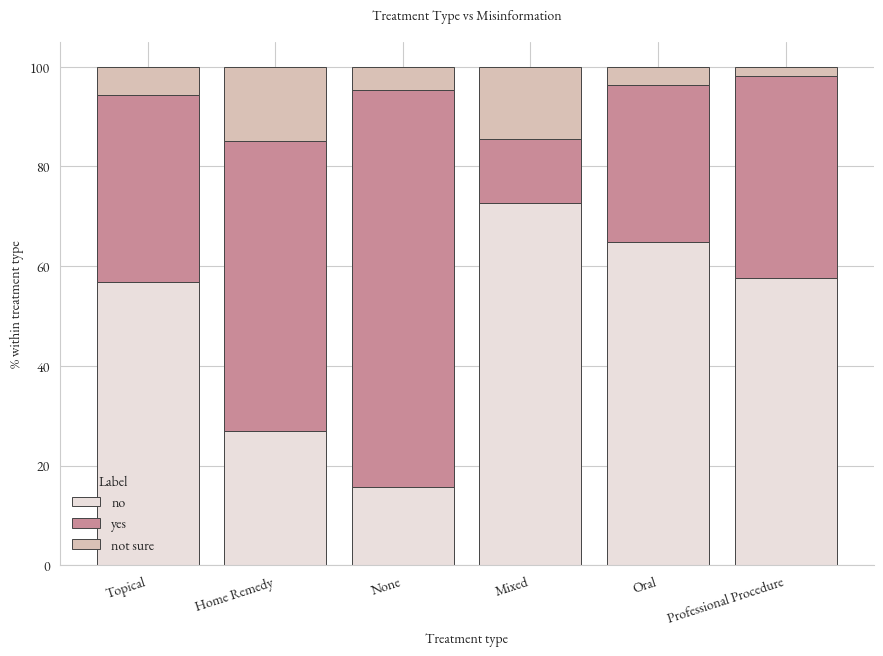

In [ ]:
# ============================================================
# 9. EDA 5: TREATMENT TYPE VS MISINFORMATION
# ============================================================

order_tt = df["treatment_type"].value_counts().head(6).index.tolist()
ct = pd.crosstab(df["treatment_type"], df["misinfo_label"], normalize="index").reindex(order_tt)

fig, ax = plt.subplots(figsize=(10.5, 6.8))
base = np.zeros(len(ct))
for col in ["no", "yes", "not_sure"]:
    vals = (ct[col] * 100).values
    ax.bar(
        range(len(ct)),
        vals,
        bottom=base,
        color=LABEL_COLORS[col],
        edgecolor=EDGE,
        linewidth=0.7,
        label=col.replace("_", " "),
    )
    base += vals
ax.set_title("Treatment Type vs Misinformation", fontsize=24, pad=16)
ax.set_ylabel("% within treatment type", fontsize=13)
ax.set_xlabel("Treatment type", fontsize=13)
ax.set_xticks(range(len(ct)))
ax.set_xticklabels([s.replace("_", " ").title() for s in ct.index], rotation=18, ha="right")
apply_axis_font(ax)
remove_spines(ax)
ax.legend(frameon=False, title="Label")



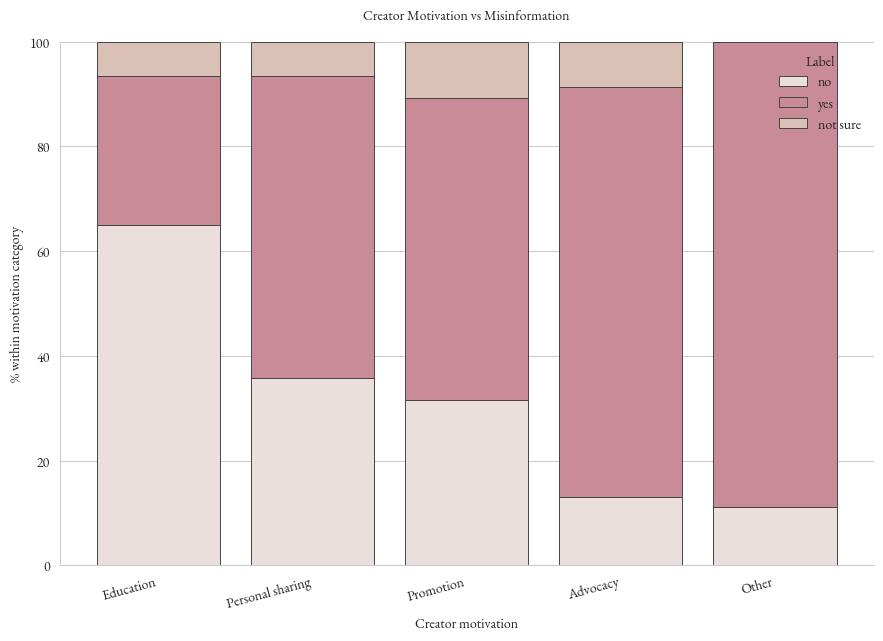

In [ ]:
# ============================================================
# 10. EDA 6: CREATOR MOTIVATION VS MISINFORMATION
# ============================================================

order = ["education", "personal_sharing", "promotion", "advocacy", "other"]
ct = pd.crosstab(df["creator_motivation"], df["misinfo_label"], normalize="index").reindex(order)

fig, ax = plt.subplots(figsize=(10.5, 6.8))
base = np.zeros(len(ct))
for col in ["no", "yes", "not_sure"]:
    vals = (ct[col] * 100).values
    ax.bar(
        range(len(ct)),
        vals,
        bottom=base,
        color=LABEL_COLORS[col],
        edgecolor=EDGE,
        linewidth=0.7,
        label=col.replace("_", " "),
    )
    base += vals
ax.set_title("Creator Motivation vs Misinformation", fontsize=24, pad=16)
ax.set_ylabel("% within motivation category", fontsize=13)
ax.set_xlabel("Creator motivation", fontsize=13)
ax.set_xticks(range(len(ct)))
ax.set_xticklabels(
    ["Education", "Personal sharing", "Promotion", "Advocacy", "Other"],
    rotation=15,
    ha="right",
)
apply_axis_font(ax)
remove_spines(ax)
ax.legend(frameon=False, title="Label")



/tmp/ipykernel_3605/3266841845.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3605/3266841845.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3605/3266841845.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved: /content/acne_misinfo_outputs/misinfo_vs_views_likes_shares.png


/tmp/ipykernel_3605/3266841845.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


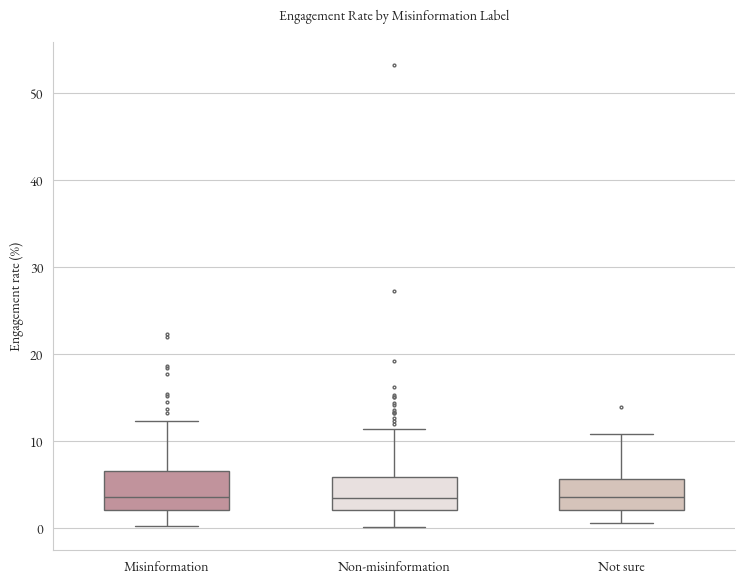

In [ ]:
# ============================================================
# 11. EDA 7: VIEWS / LIKES / SHARES + ENGAGEMENT RATE
# ============================================================

df["Label"] = df["misinfo_label"].map(
    {"yes": "Misinformation", "no": "Non-misinformation", "not_sure": "Not sure"}
)
order = ["Misinformation", "Non-misinformation", "Not sure"]
palette = {
    "Misinformation": SLIDE_PINK,
    "Non-misinformation": BLUSH,
    "Not sure": TAN,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6.8))
for ax, (col, title) in zip(axes, [("views", "Views"), ("likes", "Likes"), ("shares", "Shares")]):
    sns.boxplot(
        data=df,
        x="Label",
        y=col,
        order=order,
        palette=palette,
        width=0.55,
        ax=ax,
        fliersize=2,
    )
    ax.set_yscale("log")
    ax.set_title(title, fontsize=22, pad=14)
    ax.set_ylabel(f"{title} (log scale)", fontsize=13)
    ax.set_xlabel("")
    apply_axis_font(ax)
    remove_spines(ax)
save_figure(fig, "misinfo_vs_views_likes_shares.png")

fig, ax = plt.subplots(figsize=(8.8, 6.6))
sns.boxplot(
    data=df,
    x="Label",
    y="engagement_rate",
    order=order,
    palette=palette,
    width=0.55,
    ax=ax,
    fliersize=2,
)
ax.set_title("Engagement Rate by Misinformation Label", fontsize=24, pad=16)
ax.set_ylabel("Engagement rate (%)", fontsize=13)
ax.set_xlabel("")
apply_axis_font(ax)
remove_spines(ax)



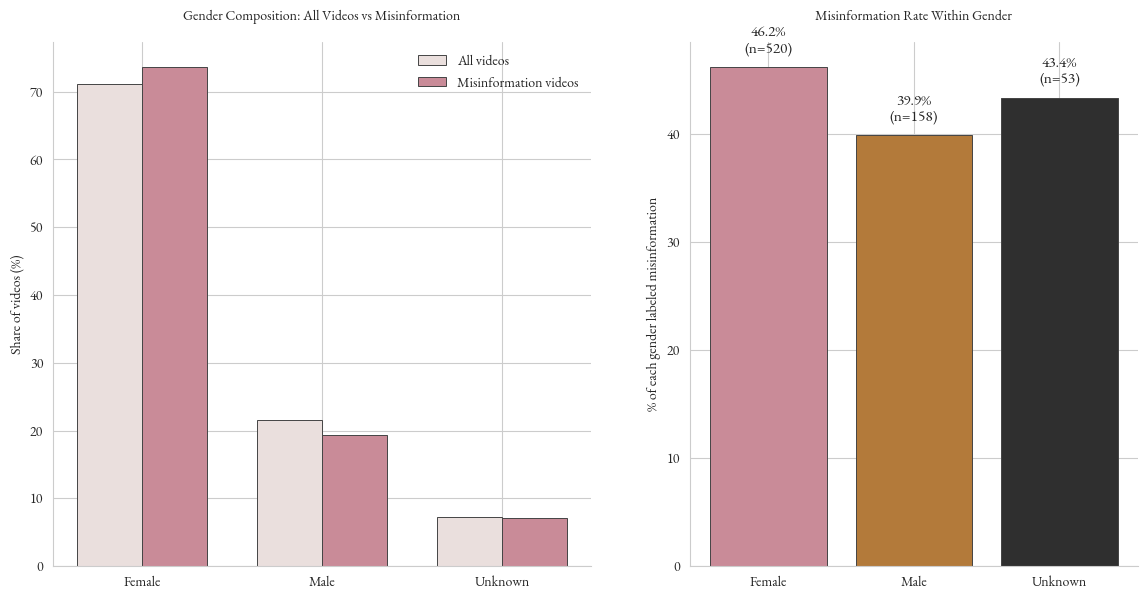

In [ ]:
# ============================================================
# 12. EDA 8: GENDER DISTRIBUTION ALL VS MISINFO
# ============================================================

order = ["female", "male", "unknown"]
all_counts = df["creator_gender"].value_counts().reindex(order).fillna(0).astype(int)
mis_counts = (
    df.loc[df["misinfo_label"] == "yes", "creator_gender"]
    .value_counts()
    .reindex(order)
    .fillna(0)
    .astype(int)
)
all_pct = (all_counts / all_counts.sum() * 100).round(1)
mis_pct = (mis_counts / mis_counts.sum() * 100).round(1)
ct = pd.crosstab(df["creator_gender"], df["misinfo_label"]).reindex(order).fillna(0)
mis_rate = ((ct["yes"] / ct.sum(axis=1)) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.8), gridspec_kw={"width_ratios": [1.2, 1]})
x = np.arange(len(order))
width = 0.36
bars1 = axes[0].bar(x - width / 2, all_pct.values, width, color=BLUSH, edgecolor=EDGE, linewidth=0.7, label="All videos")
bars2 = axes[0].bar(x + width / 2, mis_pct.values, width, color=SLIDE_PINK, edgecolor=EDGE, linewidth=0.7, label="Misinformation videos")
axes[0].set_title("Gender Composition: All Videos vs Misinformation", fontsize=22, pad=16)
axes[0].set_ylabel("Share of videos (%)", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Female", "Male", "Unknown"])
apply_axis_font(axes[0])
remove_spines(axes[0])
axes[0].legend(frameon=False)

bars3 = axes[1].bar(["Female", "Male", "Unknown"], mis_rate.values, color=[SLIDE_PINK, BROWN, CHARCOAL], edgecolor=EDGE, linewidth=0.7)
axes[1].set_title("Misinformation Rate Within Gender", fontsize=22, pad=16)
axes[1].set_ylabel("% of each gender labeled misinformation", fontsize=13)
apply_axis_font(axes[1])
remove_spines(axes[1])
for rect, pct, n in zip(bars3, mis_rate.values, ct.sum(axis=1).values):
    axes[1].text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1.0,
        f"{pct}%\n(n={int(n)})",
        ha="center",
        va="bottom",
        fontsize=11,
    )

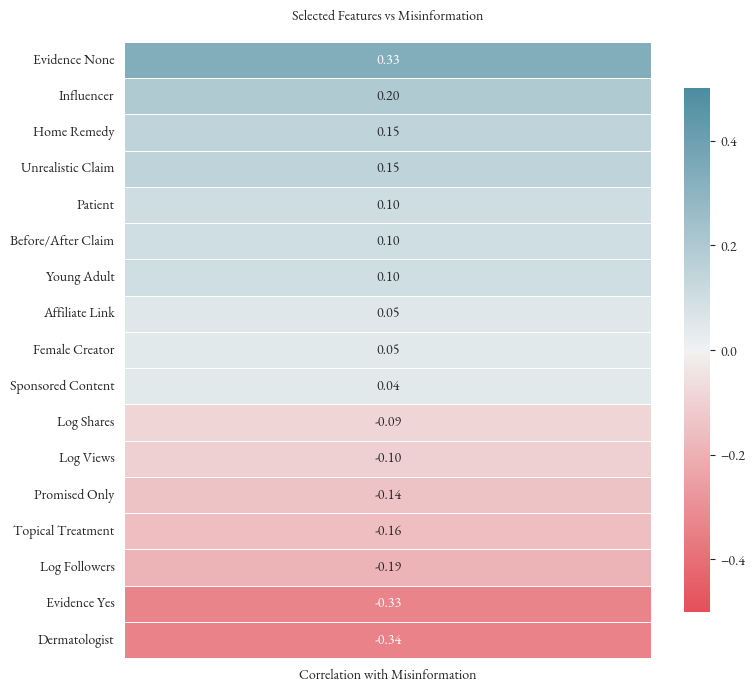

In [ ]:
# ============================================================
# 13. EDA 9: SELECTED FEATURES VS MISINFORMATION
# ============================================================

eda = df.copy()
eda["misinfo_binary"] = eda["misinfo_label"].map({"yes": 1, "no": 0, "not_sure": np.nan})
eda["log_followers"] = np.log1p(eda["creator_followers"])
eda["log_views"] = np.log1p(eda["views"])
eda["log_shares"] = np.log1p(eda["shares"])
eda["before_after"] = (eda["before_after_claim"] == "yes").astype(int)
eda["unrealistic_claim"] = (eda["unrealistic_claim_flag"] == "yes").astype(int)
eda["sponsored_yes"] = (eda["sponsored_content"] == "yes").astype(int)
eda["affiliate_yes"] = (eda["affiliate_link_present"] == "yes").astype(int)
eda["dermatologist"] = (eda["creator_type"] == "dermatologist").astype(int)
eda["influencer"] = (eda["creator_type"] == "influencer").astype(int)
eda["patient"] = (eda["creator_type"] == "patient").astype(int)
eda["topical_treatment"] = (eda["treatment_type"] == "topical").astype(int)
eda["home_remedy"] = (eda["treatment_type"] == "home_remedy").astype(int)
eda["evidence_yes"] = (eda["evidence_present"] == "yes").astype(int)
eda["evidence_none"] = (eda["evidence_present"] == "no").astype(int)
eda["promised_only"] = (eda["outcome_type"] == "promised_only").astype(int)
eda["female_creator"] = (eda["creator_gender"] == "female").astype(int)
eda["young_adult"] = (eda["creator_age_range"] == "young_adult").astype(int)
sel = eda[
    [
        "misinfo_binary",
        "log_followers",
        "log_views",
        "log_shares",
        "before_after",
        "unrealistic_claim",
        "sponsored_yes",
        "affiliate_yes",
        "dermatologist",
        "influencer",
        "patient",
        "topical_treatment",
        "home_remedy",
        "evidence_yes",
        "evidence_none",
        "promised_only",
        "female_creator",
        "young_adult",
    ]
].dropna(subset=["misinfo_binary"])

target_corr = (
    sel.corr(method="pearson")[["misinfo_binary"]]
    .drop(index="misinfo_binary")
    .sort_values("misinfo_binary", ascending=False)
)
target_corr.index = [
    "Evidence None" if i == "evidence_none" else
    "Influencer" if i == "influencer" else
    "Home Remedy" if i == "home_remedy" else
    "Unrealistic Claim" if i == "unrealistic_claim" else
    "Patient" if i == "patient" else
    "Before/After Claim" if i == "before_after" else
    "Young Adult" if i == "young_adult" else
    "Affiliate Link" if i == "affiliate_yes" else
    "Female Creator" if i == "female_creator" else
    "Sponsored Content" if i == "sponsored_yes" else
    "Log Shares" if i == "log_shares" else
    "Log Views" if i == "log_views" else
    "Promised Only" if i == "promised_only" else
    "Topical Treatment" if i == "topical_treatment" else
    "Log Followers" if i == "log_followers" else
    "Evidence Yes" if i == "evidence_yes" else
    "Dermatologist" if i == "dermatologist" else i
    for i in target_corr.index
]
target_corr.columns = ["Correlation with Misinformation"]

fig, ax = plt.subplots(figsize=(8.5, 8))
sns.heatmap(
    target_corr,
    cmap=sns.diverging_palette(10, 220, s=70, l=55, as_cmap=True),
    vmin=-0.5,
    vmax=0.5,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.85},
    ax=ax,
)
ax.set_title("Selected Features vs Misinformation", fontsize=24, pad=16)
apply_axis_font(ax)


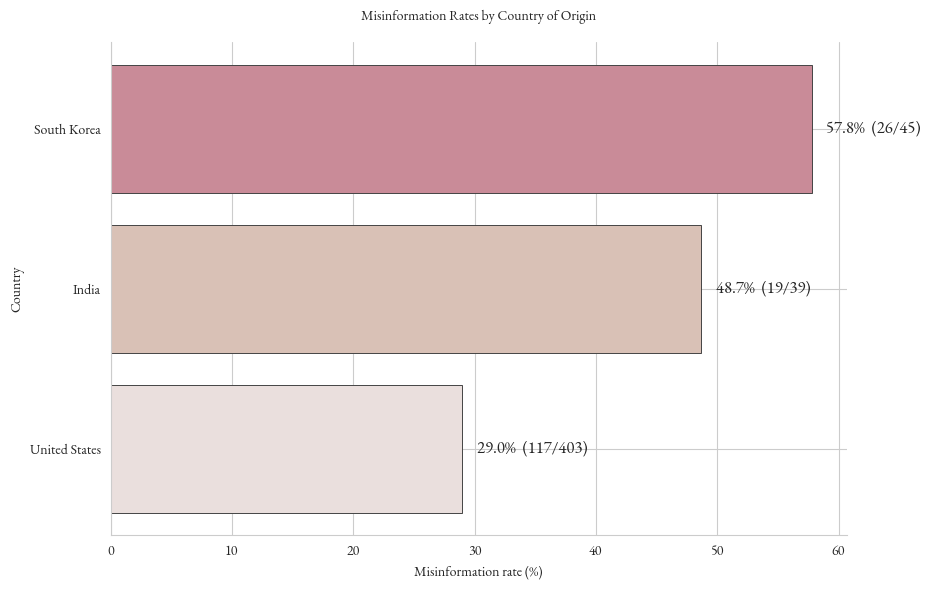

In [ ]:
# ============================================================
# 14. EDA 10: MISINFORMATION RATES BY COUNTRY
# ============================================================

keep = ["United States", "South Korea", "India"]
sub = df[df["country_origin"].isin(keep)].copy()
summary = sub.groupby("country_origin").agg(
    total_videos=("country_origin", "size"),
    misinfo_count=("misinfo_label", lambda s: (s == "yes").sum()),
)
summary["misinfo_rate"] = (summary["misinfo_count"] / summary["total_videos"] * 100).round(1)
summary = summary.loc[keep].sort_values("misinfo_rate", ascending=True)

fig, ax = plt.subplots(figsize=(9.5, 6.4))
bars = ax.barh(
    summary.index,
    summary["misinfo_rate"],
    color=[BLUSH, TAN, SLIDE_PINK],
    edgecolor=EDGE,
    linewidth=0.7,
)
for rect, rate, total, mis in zip(
    bars, summary["misinfo_rate"], summary["total_videos"], summary["misinfo_count"]
):
    ax.text(
        rect.get_width() + 1.2,
        rect.get_y() + rect.get_height() / 2,
        f"{rate}%  ({mis}/{total})",
        va="center",
        ha="left",
        fontsize=12,
    )
ax.set_title("Misinformation Rates by Country of Origin", fontsize=24, pad=16)
ax.set_xlabel("Misinformation rate (%)", fontsize=13)
ax.set_ylabel("Country", fontsize=13)
apply_axis_font(ax)
remove_spines(ax)


Text(0.5, 1.0, 'Most Used Hashtags in Acne TikTok Videos')

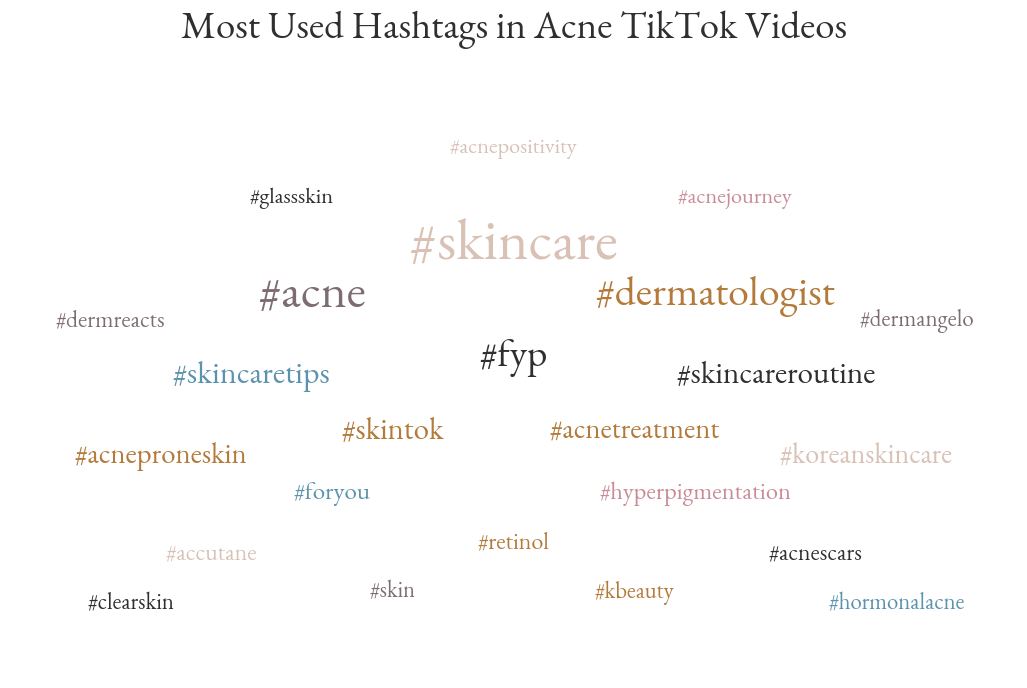

In [ ]:
# ============================================================
# 15. OPTIONAL: HASHTAG TEXT CLOUD STYLE CHART
# ============================================================

counts = Counter()
for x in df["hashtags"].fillna(""):
    for tag in [i.strip().lower() for i in str(x).split(",") if i.strip()]:
        if tag and tag not in {"none", "unknown", "unclear"}:
            counts[tag] += 1

items = counts.most_common(24)
vals = [v for _, v in items]
min_v, max_v = min(vals), max(vals)

def scale(v, lo=16, hi=42):
    if max_v == min_v:
        return (lo + hi) / 2
    return lo + (v - min_v) * (hi - lo) / (max_v - min_v)

fig, ax = plt.subplots(figsize=(13, 8), facecolor="white")
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
positions = [
    (0.50,0.70),(0.30,0.62),(0.70,0.62),(0.50,0.52),(0.24,0.49),(0.76,0.49),
    (0.38,0.40),(0.62,0.40),(0.15,0.36),(0.85,0.36),(0.32,0.30),(0.68,0.30),
    (0.50,0.22),(0.20,0.20),(0.80,0.20),(0.10,0.58),(0.90,0.58),(0.12,0.12),
    (0.88,0.12),(0.38,0.14),(0.62,0.14),(0.28,0.78),(0.72,0.78),(0.50,0.86),
]
cloud_colors = [SLIDE_PINK, SLIDE_BLUE, BROWN, TAN, CHARCOAL, "#7D6C73"]
for (word, val), (x, y) in zip(items, positions):
    ax.text(
        x, y, word,
        fontsize=scale(val),
        ha="center",
        va="center",
        color=cloud_colors[len(word) % len(cloud_colors)],
    )
ax.set_title("Most Used Hashtags in Acne TikTok Videos", fontsize=28, pad=18, color=CHARCOAL)

In [ ]:
import numpy as np
import pandas as pd

def count_items(x):
    if pd.isna(x):
        return 0
    x = str(x).strip()
    if x.lower() in {"", "none", "unknown", "unclear", "na", "nan", "no link"}:
        return 0
    return len([p.strip() for p in x.split(",") if p.strip()])

def group_rare(series, min_count=20, other_label="other"):
    s = series.fillna("missing").astype(str)
    counts = s.value_counts()
    keep = counts[counts >= min_count].index
    return s.where(s.isin(keep), other_label)

df["log_creator_followers"] = np.log1p(pd.to_numeric(df["creator_followers"], errors="coerce"))
df["log_video_duration_seconds"] = np.log1p(pd.to_numeric(df["video_duration_seconds"], errors="coerce"))

df["hashtag_count"] = df["hashtags"].apply(count_items)
df["ingredient_count"] = df["active_ingredient"].apply(count_items)
df["product_count"] = df["product_name"].apply(count_items)
df["brand_count"] = df["product_brand"].apply(count_items)

df["caption_len"] = df["caption"].fillna("").astype(str).str.len()
df["transcript_len"] = df["transcript"].fillna("").astype(str).str.len()
df["has_transcript"] = df["transcript"].fillna("").astype(str).str.strip().ne("").astype(int)
df["has_summary"] = df["transcript_summary"].fillna("").astype(str).str.strip().ne("").astype(int)

df["language_grouped"] = group_rare(df["Language"], min_count=20)
df["country_grouped"] = group_rare(df["country_origin"], min_count=20)


In [ ]:
# ============================================================
# 16. LOGISTIC REGRESSION (MAIN MODEL)
# ============================================================

logit_df = df[df["misinfo_label"].isin(["yes", "no"])].copy()
logit_df["target"] = (logit_df["misinfo_label"] == "yes").astype(int)

numeric_features = [
    "log_creator_followers",
    "engagement_rate",
    "log_video_duration_seconds",
    "hashtag_count",
    "ingredient_count",
    "product_count",
    "brand_count",
    "caption_len",
    "transcript_len",
    "has_transcript",
    "has_summary",
]

categorical_features = [
    "creator_type",
    "creator_motivation",
    "creator_age_range",
    "creator_gender",
    "intent_clarity",
    "video_format",
    "skin_condition_type",
    "skin_severity",
    "treatment_type",
    "evidence_present",
    "claim_type",
    "before_after_claim",
    "time_to_result_claim",
    "outcome_type",
    "side_effects",
    "sponsored_content",
    "affiliate_link_present",
    "language_grouped",
    "country_grouped",
]

X = logit_df[numeric_features + categorical_features]
y = logit_df["target"]

numeric_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

clf = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=5000, solver="liblinear")),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)

metrics = pd.DataFrame(
    {
        "Metric": ["Accuracy", "ROC AUC", "F1 Score", "Precision", "Recall"],
        "Value": [
            accuracy_score(y_test, pred),
            roc_auc_score(y_test, proba),
            f1_score(y_test, pred),
            precision_score(y_test, pred),
            recall_score(y_test, pred),
        ],
    }
)
metrics["Value"] = metrics["Value"].round(3)
metrics.to_csv(OUTPUT_DIR / "logistic_regression_metrics.csv", index=False)
print(metrics)

feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
coefs = clf.named_steps["model"].coef_[0]
coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefs,
        "odds_ratio": np.exp(coefs),
    }
).sort_values("coefficient", ascending=False)
coef_df.to_csv(OUTPUT_DIR / "logistic_regression_coefficients.csv", index=False)

with open(OUTPUT_DIR / "logistic_regression_classification_report.txt", "w") as f:
    f.write(classification_report(y_test, pred, digits=3))



      Metric  Value
0   Accuracy  0.818
1    ROC AUC  0.910
2   F1 Score  0.817
3  Precision  0.793
4     Recall  0.841


Saved: /content/acne_misinfo_outputs/logistic_top_predictors.png


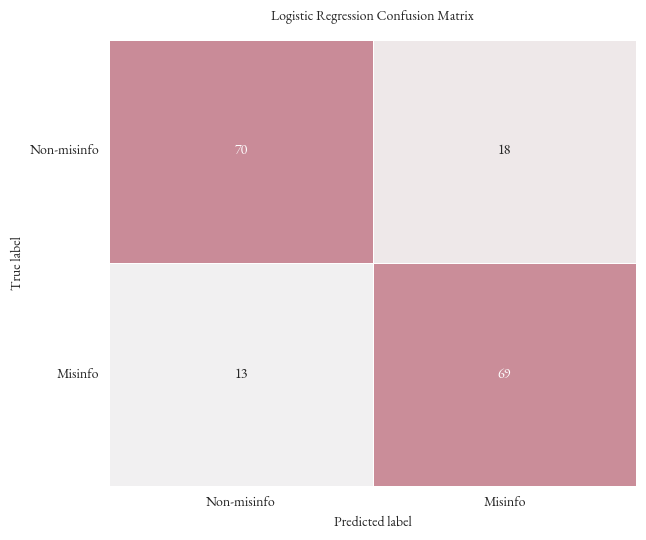

In [ ]:
# ============================================================
# 17. LOGISTIC REGRESSION CHARTS
# ============================================================

coef_df["label"] = (
    coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

pos = coef_df.sort_values("coefficient", ascending=False).head(6)
neg = coef_df.sort_values("coefficient", ascending=True).head(6)
plot_df = pd.concat([neg, pos]).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(11, 7.5))
colors = [SLIDE_BLUE if v < 0 else SLIDE_PINK for v in plot_df["coefficient"]]
bars = ax.barh(plot_df["label"], plot_df["coefficient"], color=colors, edgecolor=EDGE, linewidth=0.7)
ax.axvline(0, color=EDGE, linewidth=1)
ax.set_title("Top Logistic Regression Predictors", fontsize=24, pad=16)
ax.set_xlabel("Coefficient (positive = more likely misinformation)", fontsize=13)
ax.set_ylabel("Feature", fontsize=13)
apply_axis_font(ax)
remove_spines(ax)
for rect, val in zip(bars, plot_df["coefficient"]):
    xpos = val + 0.03 if val > 0 else val - 0.03
    ha = "left" if val > 0 else "right"
    ax.text(xpos, rect.get_y() + rect.get_height() / 2, f"{val:.2f}", va="center", ha=ha, fontsize=11)
save_figure(fig, "logistic_top_predictors.png")

fig, ax = plt.subplots(figsize=(6.8, 5.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.light_palette(SLIDE_PINK, as_cmap=True),
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)
ax.set_title("Logistic Regression Confusion Matrix", fontsize=22, pad=14)
ax.set_xlabel("Predicted label", fontsize=13)
ax.set_ylabel("True label", fontsize=13)
ax.set_xticklabels(["Non-misinfo", "Misinfo"])
ax.set_yticklabels(["Non-misinfo", "Misinfo"], rotation=0)
apply_axis_font(ax)



In [ ]:
# ============================================================
# OPTIONAL: SIMPLIFIED COMBINED-EFFECTS MODEL
# creator_type + evidence_present + treatment_type
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

combo_df = df[df["misinfo_label"].isin(["yes", "no"])].copy()
combo_df["misinfo_binary"] = (combo_df["misinfo_label"] == "yes").astype(int)

# Keep only the combinations we actually want to compare
combo_df = combo_df[
    combo_df["creator_type"].isin(["dermatologist", "influencer", "patient", "other"])
].copy()

combo_df = combo_df[
    combo_df["evidence_present"].isin(["yes", "no"])
].copy()

combo_df = combo_df[
    combo_df["treatment_type"].isin(["topical", "home_remedy", "none"])
].copy()

# Drop sparse combinations
cell_counts = (
    combo_df.groupby(["creator_type", "evidence_present", "treatment_type"])
    .size()
    .reset_index(name="n")
)

valid_cells = cell_counts[cell_counts["n"] >= 8][
    ["creator_type", "evidence_present", "treatment_type"]
]

combo_df = combo_df.merge(
    valid_cells,
    on=["creator_type", "evidence_present", "treatment_type"],
    how="inner"
)

# Simpler additive model instead of full interaction model
combo_model = smf.logit(
    "misinfo_binary ~ C(creator_type) + C(evidence_present) + C(treatment_type)",
    data=combo_df
).fit(disp=False)

# Predicted probabilities for observed valid combinations
pred_grid = valid_cells.copy()
pred_grid["pred_misinfo"] = combo_model.predict(pred_grid)
pred_grid["pred_non_misinfo"] = 1 - pred_grid["pred_misinfo"]

# Make readable labels
pred_grid["label"] = (
    pred_grid["creator_type"].str.title()
    + " | Evidence: " + pred_grid["evidence_present"].str.title()
    + " | " + pred_grid["treatment_type"].str.replace("_", " ").str.title()
)

pred_grid = pred_grid.sort_values("pred_misinfo", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    pred_grid["label"],
    pred_grid["pred_misinfo"] * 100,
    color=SLIDE_BLUE,
    edgecolor=EDGE,
    linewidth=0.7
)

for bar, val in zip(bars, pred_grid["pred_misinfo"] * 100):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=11
    )

ax.set_title("Predicted Misinformation by Creator Type, Evidence, and Treatment", fontsize=22, pad=16)
ax.set_xlabel("Predicted misinformation probability (%)", fontsize=13)
ax.set_ylabel("")
apply_axis_font(ax)
remove_spines(ax)
save_figure(fig, "creator_type_evidence_treatment_simplified.png")

pred_grid[["creator_type", "evidence_present", "treatment_type", "pred_misinfo", "pred_non_misinfo"]]


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Saved: /content/acne_misinfo_outputs/creator_type_evidence_treatment_simplified.png


,creator_type,evidence_present,treatment_type,pred_misinfo,pred_non_misinfo
17,patient,no,none,1.000000,4.579461e-10
7,influencer,no,none,0.978454,2.154604e-02
11,other,no,none,0.950570,4.942983e-02
6,influencer,no,home_remedy,0.812822,1.871780e-01
8,influencer,no,topical,0.734865,2.651346e-01
10,other,no,home_remedy,0.647753,3.522467e-01
12,other,no,topical,0.539959,4.600414e-01
2,dermatologist,no,topical,0.243243,7.567568e-01
5,dermatologist,yes,topical,0.046512,9.534884e-01


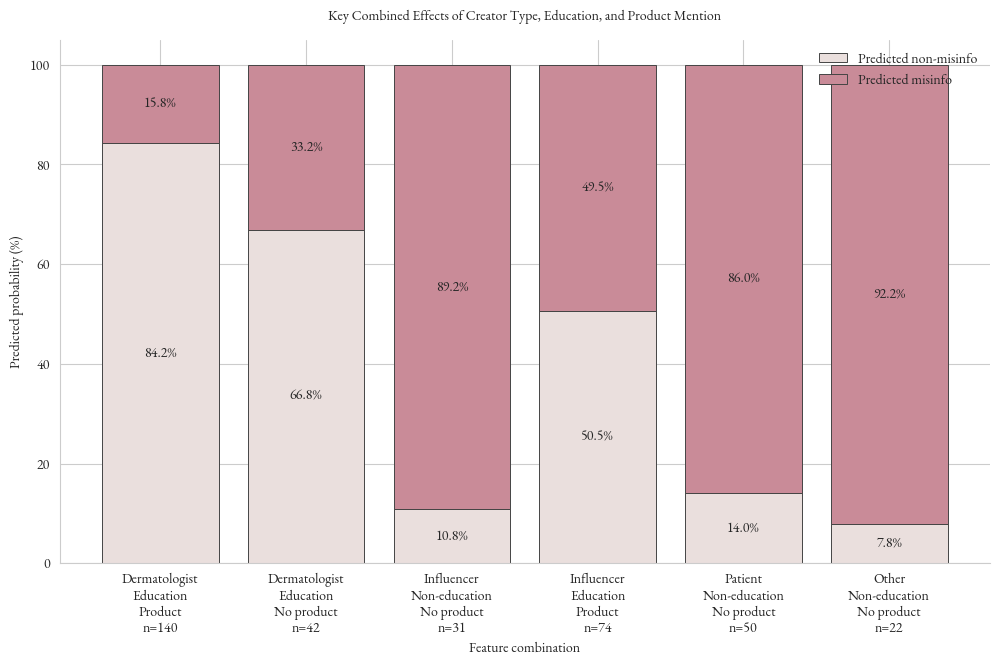

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

combo_plot = pd.DataFrame({
    "label": [
        "Dermatologist\nEducation\nProduct\nn=140",
        "Dermatologist\nEducation\nNo product\nn=42",
        "Influencer\nNon-education\nNo product\nn=31",
        "Influencer\nEducation\nProduct\nn=74",
        "Patient\nNon-education\nNo product\nn=50",
        "Other\nNon-education\nNo product\nn=22",
    ],
    "pred_non_misinfo": [84.2, 66.8, 10.8, 50.5, 14.0, 7.8],
    "pred_misinfo": [15.8, 33.2, 89.2, 49.5, 86.0, 92.2],
})

fig, ax = plt.subplots(figsize=(12, 6.8))

x = np.arange(len(combo_plot))

ax.bar(
    x,
    combo_plot["pred_non_misinfo"],
    color=BLUSH,
    edgecolor=EDGE,
    linewidth=0.7,
    label="Predicted non-misinfo"
)

ax.bar(
    x,
    combo_plot["pred_misinfo"],
    bottom=combo_plot["pred_non_misinfo"],
    color=SLIDE_PINK,
    edgecolor=EDGE,
    linewidth=0.7,
    label="Predicted misinfo"
)

for i, row in combo_plot.iterrows():
    ax.text(
        i,
        row["pred_non_misinfo"] / 2,
        f'{row["pred_non_misinfo"]:.1f}%',
        ha="center",
        va="center",
        fontsize=10
    )
    ax.text(
        i,
        row["pred_non_misinfo"] + row["pred_misinfo"] / 2,
        f'{row["pred_misinfo"]:.1f}%',
        ha="center",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Key Combined Effects of Creator Type, Education, and Product Mention",
    fontsize=20,
    pad=14
)
ax.set_ylabel("Predicted probability (%)", fontsize=12)
ax.set_xlabel("Feature combination", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(combo_plot["label"], fontsize=10)
ax.set_ylim(0, 105)

apply_axis_font(ax)
remove_spines(ax)
ax.legend(frameon=False)



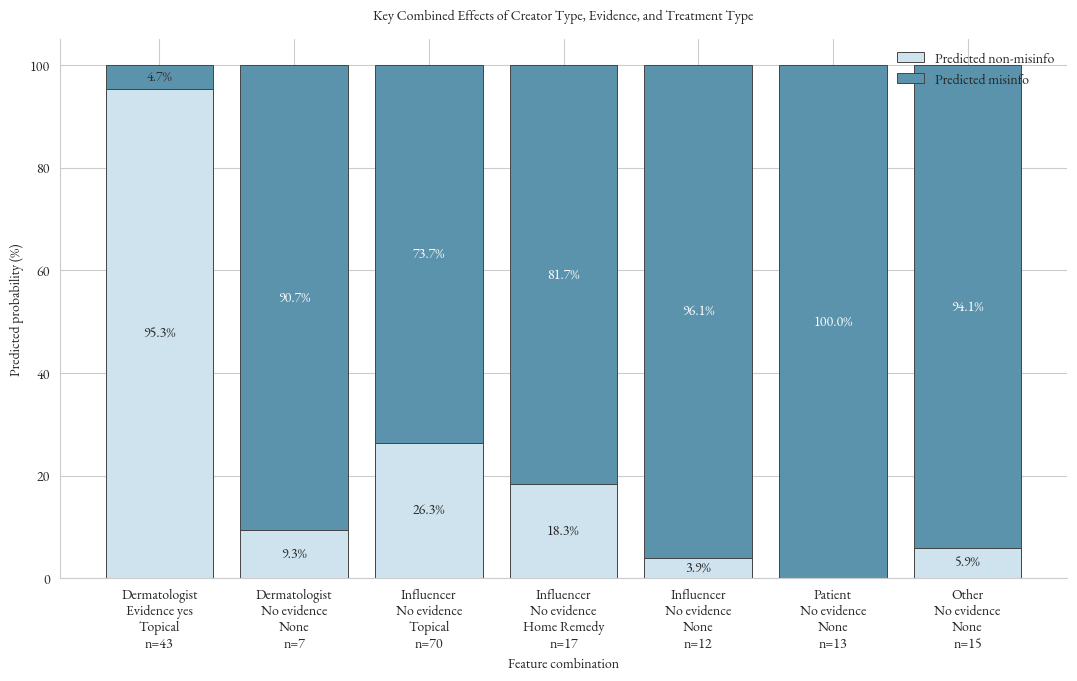

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

combo_plot2 = pd.DataFrame({
    "label": [
        "Dermatologist\nEvidence yes\nTopical\nn=43",
        "Dermatologist\nNo evidence\nNone\nn=7",
        "Influencer\nNo evidence\nTopical\nn=70",
        "Influencer\nNo evidence\nHome Remedy\nn=17",
        "Influencer\nNo evidence\nNone\nn=12",
        "Patient\nNo evidence\nNone\nn=13",
        "Other\nNo evidence\nNone\nn=15",
    ],
    "pred_non_misinfo": [95.3, 9.3, 26.3, 18.3, 3.9, 0.0, 5.9],
    "pred_misinfo": [4.7, 90.7, 73.7, 81.7, 96.1, 100.0, 94.1],
})

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(combo_plot2))

ax.bar(
    x,
    combo_plot2["pred_non_misinfo"],
    color="#CFE3EE",
    edgecolor=EDGE,
    linewidth=0.7,
    label="Predicted non-misinfo"
)

ax.bar(
    x,
    combo_plot2["pred_misinfo"],
    bottom=combo_plot2["pred_non_misinfo"],
    color=SLIDE_BLUE,
    edgecolor=EDGE,
    linewidth=0.7,
    label="Predicted misinfo"
)

for i, row in combo_plot2.iterrows():
    if row["pred_non_misinfo"] > 0:
        ax.text(
            i,
            row["pred_non_misinfo"] / 2,
            f'{row["pred_non_misinfo"]:.1f}%',
            ha="center",
            va="center",
            fontsize=10
        )
    ax.text(
        i,
        row["pred_non_misinfo"] + row["pred_misinfo"] / 2,
        f'{row["pred_misinfo"]:.1f}%',
        ha="center",
        va="center",
        fontsize=10,
        color="white" if row["pred_misinfo"] > 55 else CHARCOAL
    )

ax.set_title(
    "Key Combined Effects of Creator Type, Evidence, and Treatment Type",
    fontsize=20,
    pad=14
)
ax.set_ylabel("Predicted probability (%)", fontsize=12)
ax.set_xlabel("Feature combination", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(combo_plot2["label"], fontsize=10)
ax.set_ylim(0, 105)

apply_axis_font(ax)
remove_spines(ax)
ax.legend(frameon=False)



**Prompt used:**


Create a bar chart comparing creator type and misinformation labels.


Create a bar chart showing the relationship between evidence presence and misinformation labels.

Create a scatter plot comparing follower count and misinformation labels.

Create a bar chart showing misinformation frequency across different acne treatment types.

Create a grouped bar chart comparing creator motivation and misinformation labels.

Create boxplots for views, likes, shares, and engagement rate grouped by misinformation label.

Create a pie chart showing the gender distribution of creators.

Create a bar chart comparing misinformation rates across countries.

Create a bar chart showing the distribution of creator age ranges.

Create a horizontal bar chart showing the top 10 most frequently used hashtags.

Create a correlation heatmap using numerical engagement variables such as views, likes, shares, comments, engagement rate, and follower count.

Create a pairplot for numerical variables colored by misinformation label.

Create a heatmap showing missing values across the dataset.
Create a logistic regression model to predict misinformation labels using creator type, evidence presence, treatment type, engagement metrics, and follower count.

Create a bar chart showing logistic regression coefficients ranked from highest positive to highest negative effect.
Create a confusion matrix visualization for the logistic regression model predictions.

Create an ROC curve to evaluate logistic regression model performance.

Create a feature importance chart based on logistic regression coefficient magnitudes.

Create a histogram showing the distribution of predicted misinformation probabilities from the logistic regression model.


